In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_csv("../data/raw/superstore.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Order Day"] = df["Order Date"].dt.day_name()
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [4]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print("=" * 50)
print("OVERALL BUSINESS PERFORMANCE")
print("=" * 50)

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Orders     : {total_orders}")
print(f"Unique Customers : {total_customers}")

OVERALL BUSINESS PERFORMANCE
Total Sales      : $2,297,200.86
Total Profit     : $286,397.02
Total Orders     : 5009
Unique Customers : 793


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


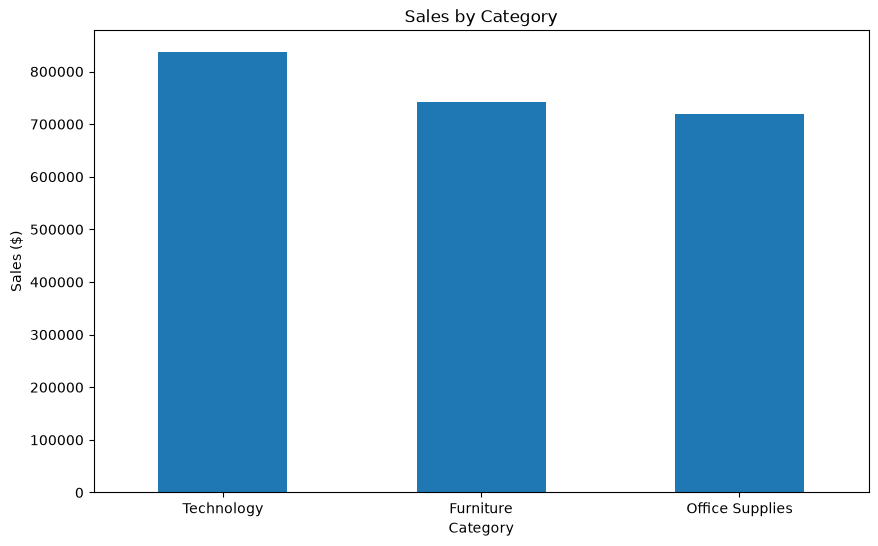

In [5]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.show()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


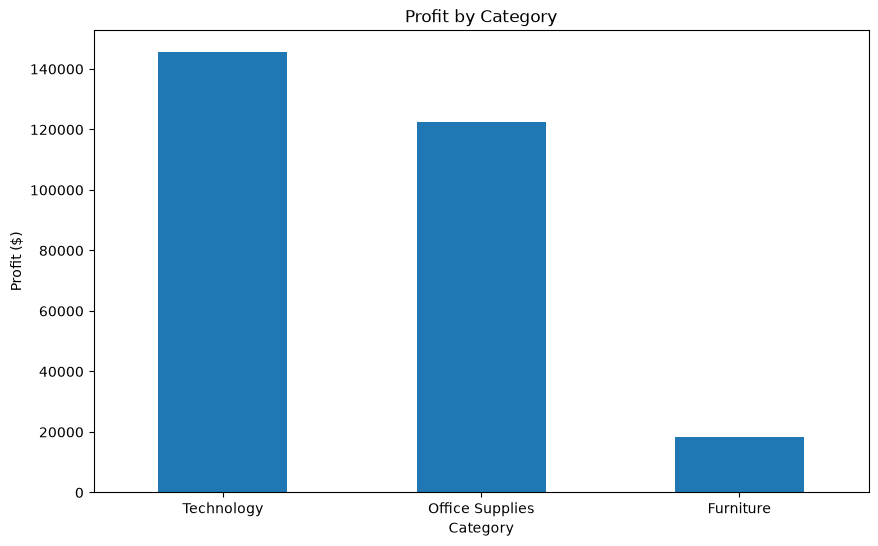

In [6]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.show()

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


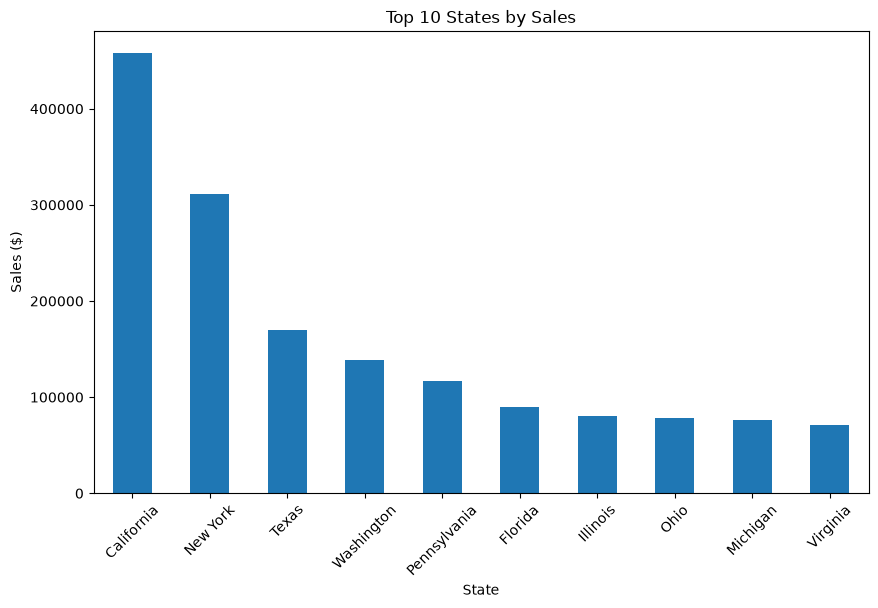

In [7]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_states)

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.show()

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


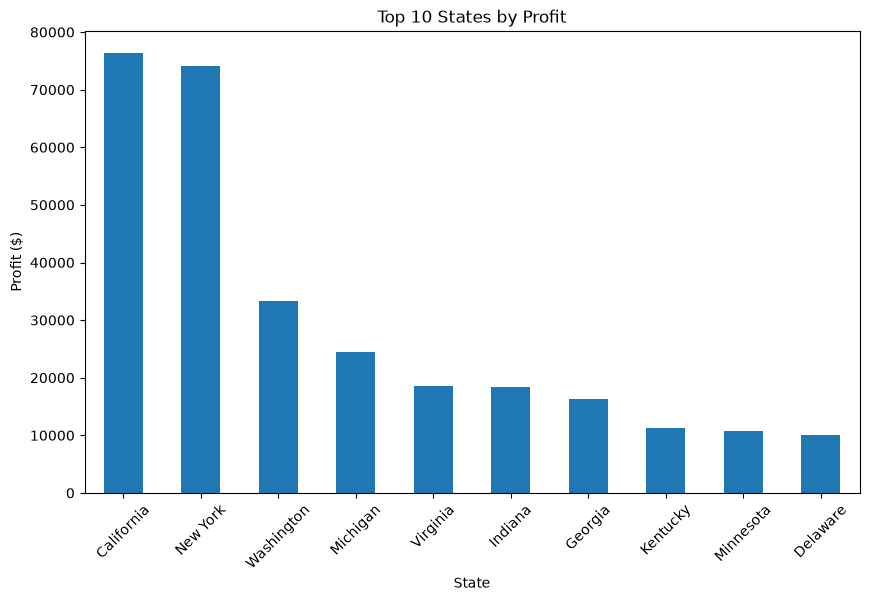

In [8]:
top_profit_states = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_profit_states)

top_profit_states.plot(kind="bar")

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)

plt.show()

# Key Business Insights

- Total sales exceeded **$2.29M** across **5,009 orders**.
- The business generated approximately **$286K** in total profit.
- **Technology** is the highest-performing category in both sales and profit.
- **Furniture** has strong sales but significantly lower profitability, indicating margin challenges.
- **California** and **New York** are the company's most valuable markets.
- **Texas** ranks high in sales but not in profit, suggesting profitability issues that require further investigation.

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


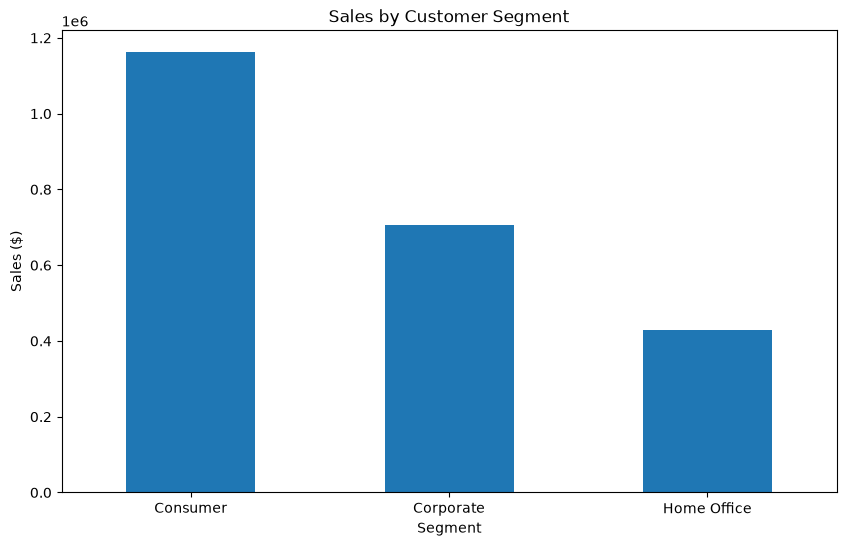

In [9]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)

segment_sales.plot(
    kind="bar",
    title="Sales by Customer Segment"
)

plt.xlabel("Segment")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.show()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


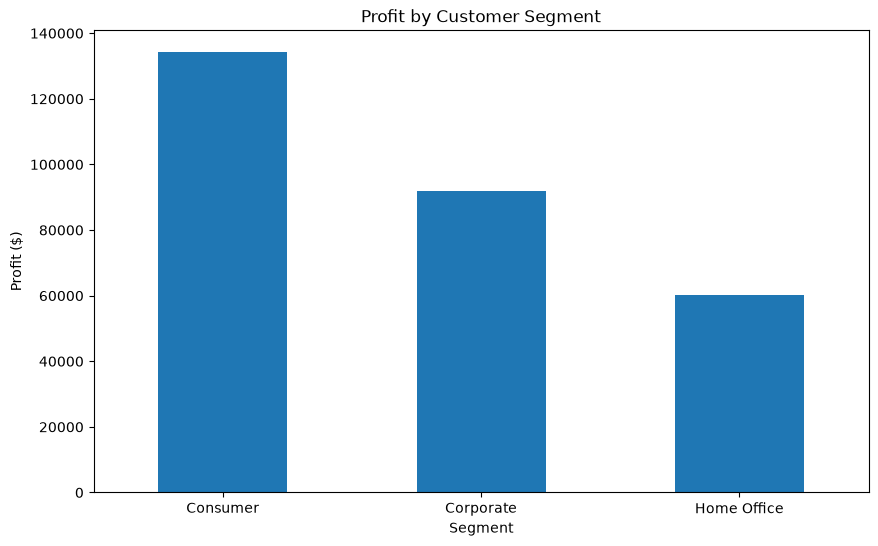

In [10]:
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_profit)

segment_profit.plot(
    kind="bar",
    title="Profit by Customer Segment"
)

plt.xlabel("Segment")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.show()

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


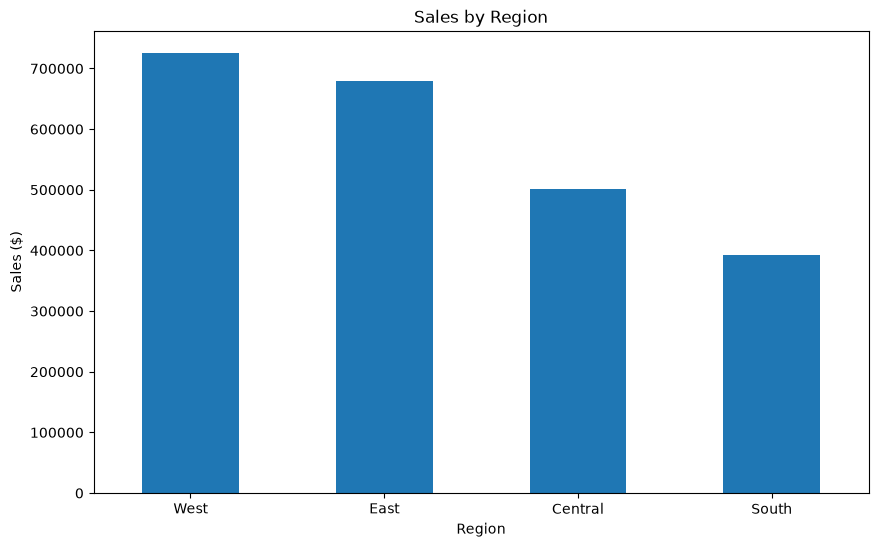

In [11]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

region_sales.plot(
    kind="bar",
    title="Sales by Region"
)

plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.show()

Order Month Name
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64


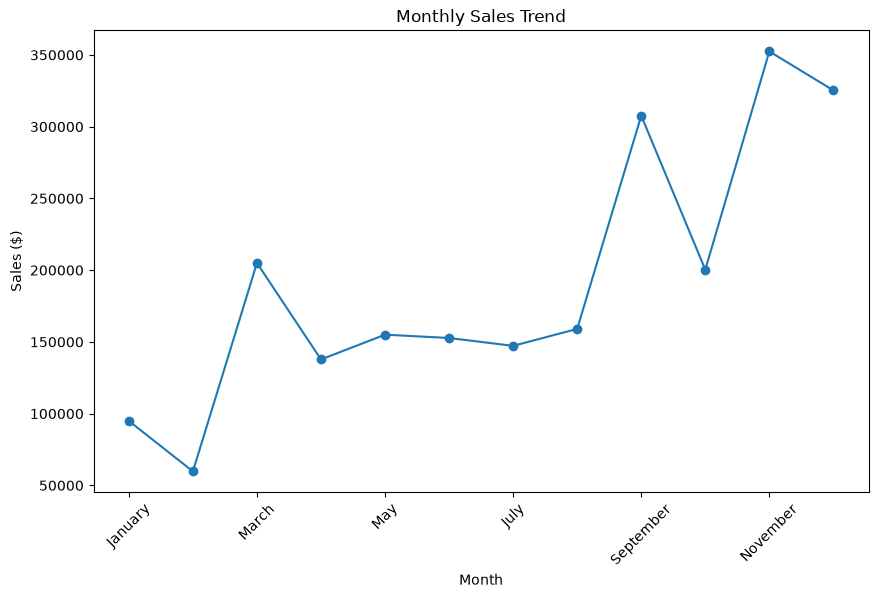

In [12]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
      .sum()
      .reindex(month_order)
)

print(monthly_sales)

monthly_sales.plot(
    kind="line",
    marker="o",
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.show()

Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


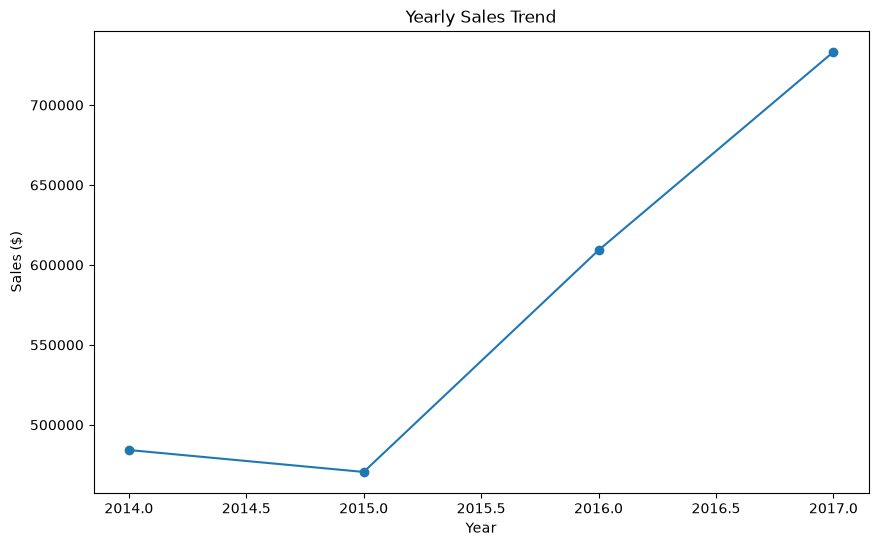

In [13]:
yearly_sales = (
    df.groupby("Order Year")["Sales"]
      .sum()
)

print(yearly_sales)

yearly_sales.plot(
    kind="line",
    marker="o",
    title="Yearly Sales Trend"
)

plt.xlabel("Year")
plt.ylabel("Sales ($)")

plt.show()

In [14]:
print("=" * 50)
print("SHIPPING PERFORMANCE")
print("=" * 50)

print(f"Average Shipping Days : {df['Shipping Days'].mean():.2f}")
print(f"Minimum Shipping Days : {df['Shipping Days'].min()}")
print(f"Maximum Shipping Days : {df['Shipping Days'].max()}")

SHIPPING PERFORMANCE
Average Shipping Days : 3.96
Minimum Shipping Days : 0
Maximum Shipping Days : 7


# Customer & Regional Insights

### Key Findings

- The Consumer segment contributes the highest sales and profit.
- The West region is the company's strongest market by revenue.
- Sales increase significantly during September–December, indicating seasonal demand.
- The business shows consistent growth from 2015 to 2017.
- Average shipping time is approximately four days.

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


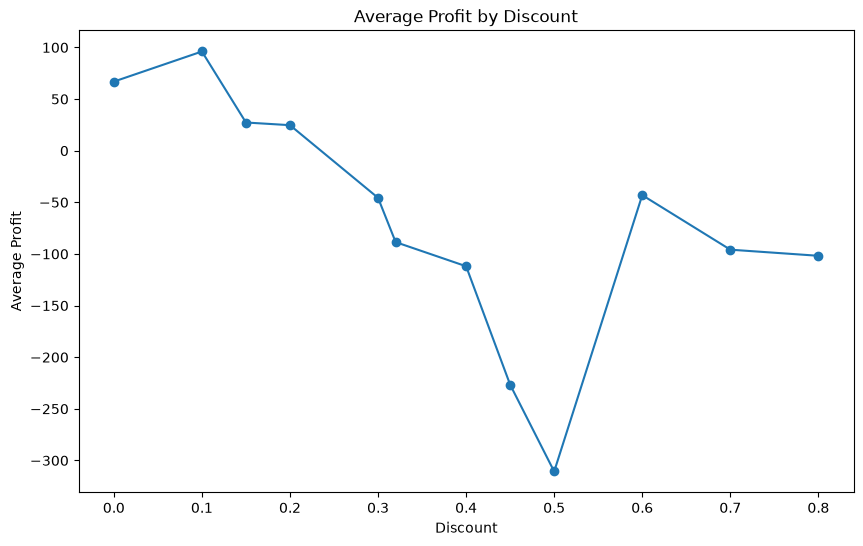

In [15]:
discount_profit = (
    df.groupby("Discount")["Profit"]
      .mean()
)

print(discount_profit)

discount_profit.plot(
    kind="line",
    marker="o",
    title="Average Profit by Discount"
)

plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


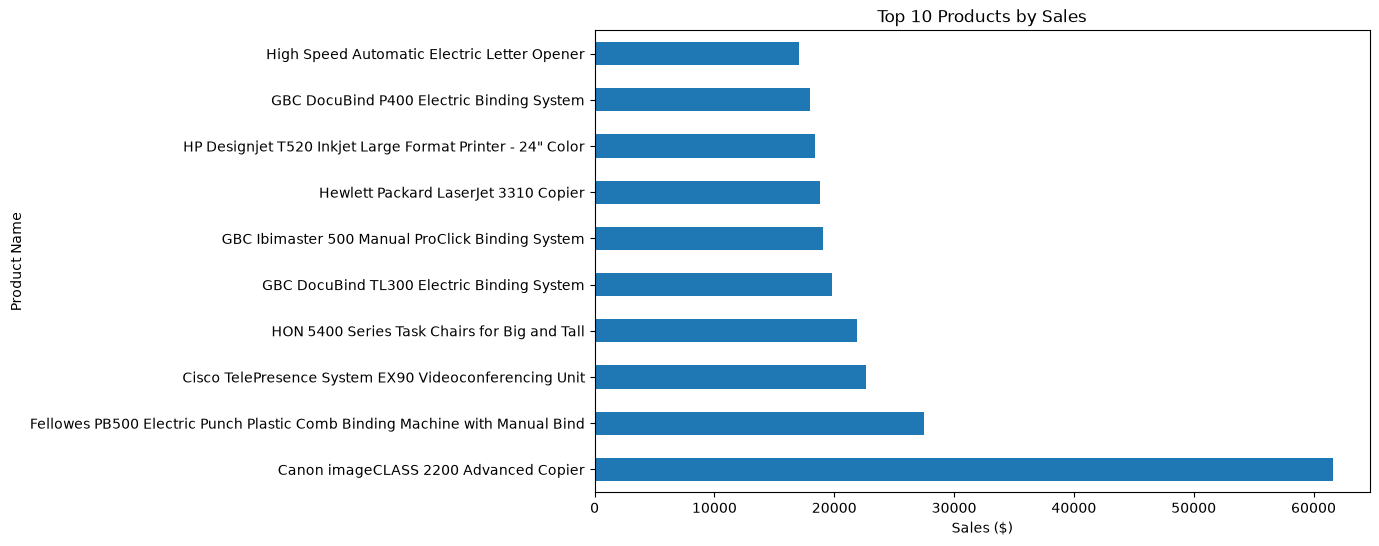

In [16]:
top_products_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products_sales)

top_products_sales.plot(
    kind="barh",
    title="Top 10 Products by Sales"
)

plt.xlabel("Sales ($)")

plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


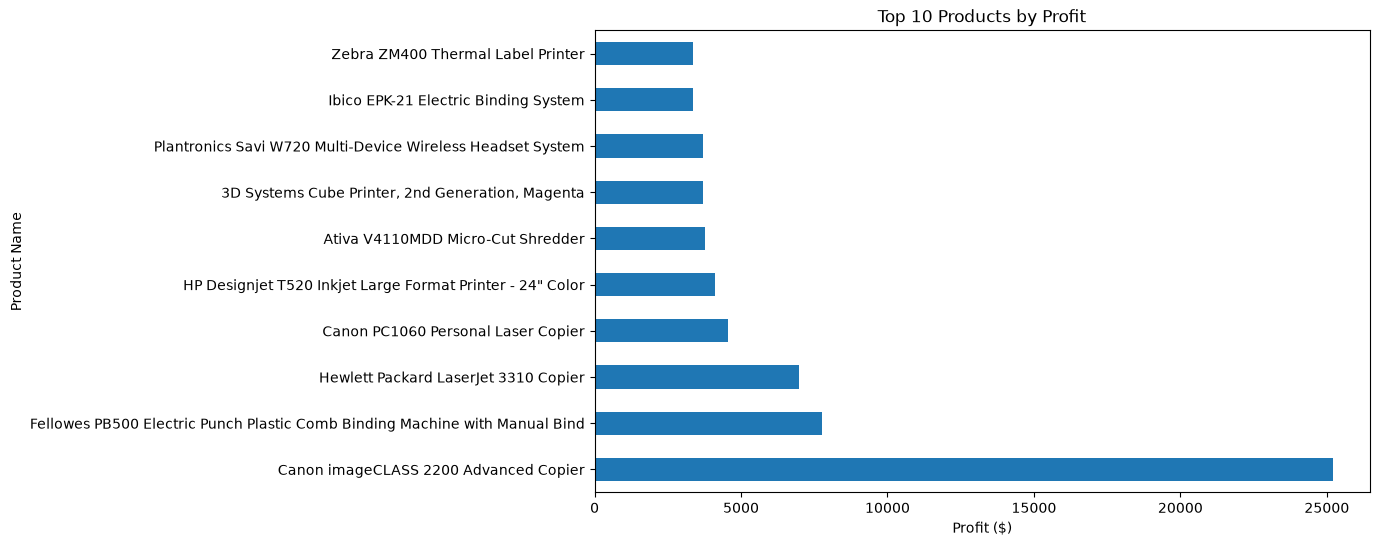

In [17]:
top_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products_profit)

top_products_profit.plot(
    kind="barh",
    title="Top 10 Products by Profit"
)

plt.xlabel("Profit ($)")

plt.show()

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


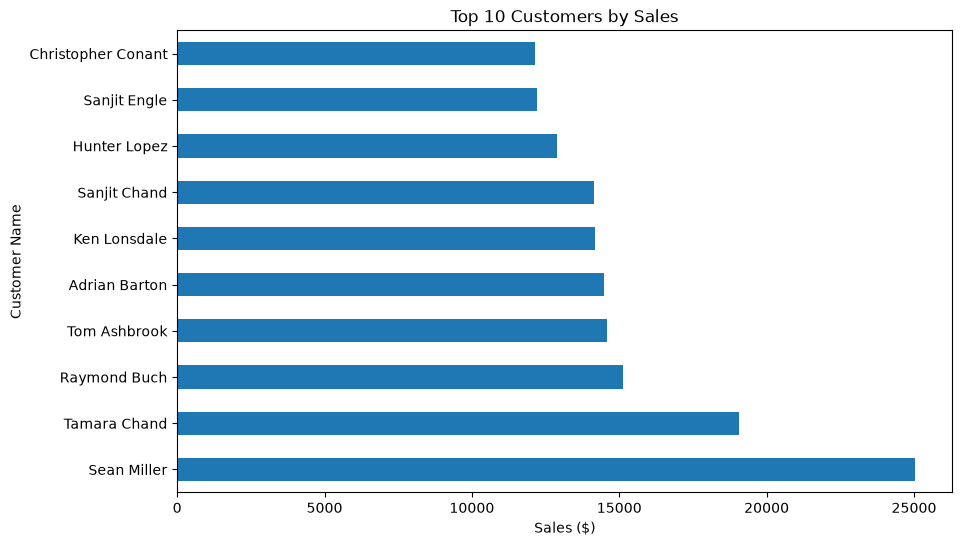

In [18]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

top_customers.plot(
    kind="barh",
    title="Top 10 Customers by Sales"
)

plt.xlabel("Sales ($)")

plt.show()

In [19]:
numeric_df = df[["Sales", "Profit", "Discount", "Quantity", "Shipping Days"]]

corr = numeric_df.corr()

print(corr)

                  Sales    Profit  Discount  Quantity  Shipping Days
Sales          1.000000  0.479064 -0.028190  0.200795      -0.007354
Profit         0.479064  1.000000 -0.219487  0.066253      -0.004649
Discount      -0.028190 -0.219487  1.000000  0.008623       0.000408
Quantity       0.200795  0.066253  0.008623  1.000000       0.018298
Shipping Days -0.007354 -0.004649  0.000408  0.018298       1.000000


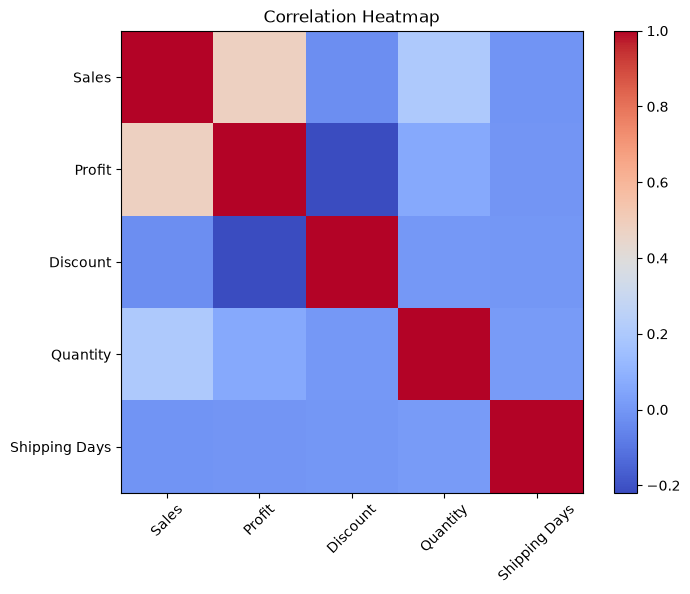

In [20]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

# Executive Summary

## Project Overview

This project analyzes nearly **10,000 retail transactions** to identify trends in sales, profitability, customer behavior, and operational performance.

## Key Findings

- Total sales exceeded **$2.29M** with **$286K** in profit.
- Technology is the highest-performing product category in both revenue and profitability.
- Furniture generates strong revenue but significantly lower profit margins.
- The Consumer segment contributes the highest sales and profit.
- California and New York are the strongest-performing states.
- Sales peak during **September–December**, indicating seasonal demand.
- Discounts above **20%** reduce profitability, with 50% discounts producing the largest losses.
- The Canon imageCLASS 2200 Advanced Copier is the top product by both sales and profit.
- Average shipping time is approximately **4 days**.

## Business Recommendations

- Focus investment on high-margin Technology products.
- Review Furniture pricing and discount strategies to improve profitability.
- Limit excessive discounting to protect profit margins.
- Increase inventory and marketing efforts before the September–December sales peak.
- Strengthen customer retention programs for high-value customers.